# Week 2 : Day 1 Text Embeddings and Semantic Search

### Written by: Hafiza Mehak Arif

### Date: 15-June-2026


# Task 1: Generate & Compare Embeddings


In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

#### Loading Model


In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")


In [3]:
sentences = ["dog", "puppy", "car"]

embeddings = model.encode(sentences)

print("Shape:", embeddings.shape)

Shape: (3, 384)


#### Calculating Cosine Similirity


In [4]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    return dot_product / (norm_vec1 * norm_vec2)

dog_puppy = cosine_similarity(embeddings[0], embeddings[1])
dog_car = cosine_similarity(embeddings[0], embeddings[2])

print(f"Dog vs Puppy: {dog_puppy:.4f}")
print(f"Dog vs Car: {dog_car:.4f}")

Dog vs Puppy: 0.8040
Dog vs Car: 0.4756


#### Similirity Matrix


In [5]:
similarity_matrix = np.zeros((len(sentences), len(sentences)))

for i in range(len(sentences)):
    for j in range(len(sentences)):
        similarity_matrix[i][j] = cosine_similarity(
            embeddings[i],
            embeddings[j]
        )
print(np.round(similarity_matrix, 2))        

[[1.   0.8  0.48]
 [0.8  1.   0.46]
 [0.48 0.46 1.  ]]


#### Sentence Similarity Heatmap


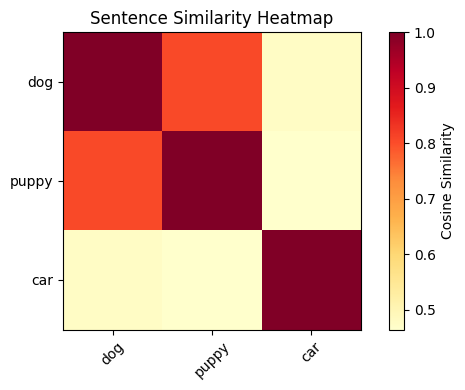

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.imshow(similarity_matrix, cmap="YlOrRd")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(sentences)), sentences, rotation=45)
plt.yticks(range(len(sentences)), sentences)

plt.title("Sentence Similarity Heatmap")
plt.tight_layout()

plt.show()

# Task 2: Build Simple Semantic Search


In [6]:
import random

# Knowledge base: collection of short factual sentences
knowledge_base = [
    "Machine learning enables computers to learn from data.",
    "Deep learning uses neural networks with many layers.",
    "Python is widely used in data science.",
    "Machine learning lets computers learn from data.",
    "Neural networks are inspired by the human brain.",
    "Overfitting means a model memorizes training data too well.",
    "Supervised learning uses labeled data for training.",
    "Unsupervised learning finds patterns without labels.",
    "Deep learning uses multiple layers of neurons.",
    "Good data quality improves model accuracy.",
    "Reinforcement learning trains agents using rewards.",
    "Gradient descent helps minimize prediction error.",
    "Python is known for its simple syntax.",
    "A bug is an error in code.",
    "Too much sugar can harm the heart.",
    "Exercise boosts mood and energy levels.",
    "Fruits and vegetables provide key vitamins.",
    "Whole grains have more nutrients than refined grains.",
    "Booking flights early often saves money.",
    "A passport is needed for most international trips.",
    "Carrying local currency helps with small purchases.",
    "Travel insurance covers unexpected emergencies.",
    "Packing light makes travel easier.",
    "Compound interest grows savings over time.",
    "Diversification helps reduce investment risk.",
    "Emergency funds cover unplanned expenses.",
    "Credit scores affect loan approval.",
    "Regular exercise improves heart health.",
    "Vegetables are rich in vitamins and minerals.",
    "Healthy recipes often include fresh ingredients.",
    "Water supports nearly every body function.",
    "Protein helps build and repair muscle.",
    "Fiber supports healthy digestion.",
    "Inflation reduces the value of money over time.",
    "Functions help organize and reuse code.",
    "Loops repeat actions until a condition ends.",
    "Variables store data for later use.",
    "Vitamin D supports strong bones.",
    "Saving early lets compounding work in your favor.",
    "Time zone changes can cause jet lag.",
    "Learning local customs shows respect.",
    "Public transport is often cheaper than taxis.",
    "Debugging means finding and fixing errors.",
    "APIs let programs communicate with each other.",
    "Version control tracks code changes over time.",
    "Clean code is easier to read and maintain.",
    "Sleep helps the body and mind recover.",
    "Football is one of the most popular sports.",
    "Football is the world's most popular sport.",
    "The Olympics happen every four years.",
    "Stretching before exercise lowers injury risk.",
    "Teamwork is essential in team sports.",
    "A marathon covers 26.2 miles.",
    "Tennis is scored in sets and games.",
    "A basketball team has five players on court.",
    "Cardio exercise strengthens the heart.",
    "Investing early helps build wealth.",
    "Budgeting tracks income and spending.",
    
]
embeddings = model.encode(knowledge_base)
print("Embeddings Generated Successfully!")

Embeddings Generated Successfully!


## Semantic Search


In [7]:
def semantic_search(query, knowledge_base, embeddings, top_k=3):
    # Embed the query
    query_embedding = model.encode(query)

    # Compute similarity scores
    scores = []

    for i, embedding in enumerate(embeddings):
        similarity = cosine_similarity(query_embedding, embedding)
        scores.append((knowledge_base[i], similarity))

    # Sort by similarity (highest first)
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Return top K results
    return scores[:top_k]

### Testing


In [8]:
results = semantic_search(
    " Python Programming ",
    knowledge_base,
    embeddings,
    top_k=5
)

for text, score in results:
    print(f"{score:.4f} → {text}")

0.6557 → Python is known for its simple syntax.
0.6390 → Python is widely used in data science.
0.3589 → APIs let programs communicate with each other.
0.3254 → Functions help organize and reuse code.
0.2754 → Variables store data for later use.


In [9]:
results = semantic_search(
    "healthy food",
    knowledge_base,
    embeddings,
    top_k=6
)

for text, score in results:
    print(f"{score:.4f} → {text}")

0.6418 → Healthy recipes often include fresh ingredients.
0.5159 → Vegetables are rich in vitamins and minerals.
0.5022 → Fruits and vegetables provide key vitamins.
0.4467 → Fiber supports healthy digestion.
0.4242 → Whole grains have more nutrients than refined grains.
0.3267 → Regular exercise improves heart health.


# Task 3: Building a Simple Chatbot


In [10]:
from groq import Groq
client = Groq(api_key=os.getenv("GROQ_API_KEY"))
print(os.getenv("GROQ_API_KEY") is not None)

True


In [11]:
# Model
MODEL_NAME = "llama-3.3-70b-versatile"

# System prompt
messages = [
    {
        "role": "system",
        "content": (
            "You are a friendly study assistant for AI engineering students. "
            "Explain concepts clearly and concisely. "
            "Keep responses short by default (3-5 sentences). "
            "Ask follow-up questions only when necessary."
        )
    }
]

# Token tracking
total_prompt_tokens = 0
total_completion_tokens = 0
total_tokens_used = 0

# Keep only the last 3 user-assistant exchanges
MAX_HISTORY = 6


def trim_history(messages):
    """
    Preserve the system prompt and keep only recent exchanges.
    """
    if len(messages) > MAX_HISTORY + 1:
        return [messages[0]] + messages[-MAX_HISTORY:]
    return messages


def get_chatbot_response(messages):
    """
    Send messages to Groq and return the response and usage.
    """
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        temperature=0.3,
        max_completion_tokens=100
    )

    if not response.choices:
        raise ValueError("Invalid response received from the API.")

    assistant_reply = response.choices[0].message.content

    return assistant_reply, response.usage


# Interactive chatbot
while True:
    user_input = input("\nYou: ").strip()

    if user_input.lower() in ["exit", "quit", "bye"]:
        print("\nChatbot: Goodbye!")
        break

    messages.append(
        {
            "role": "user",
            "content": user_input
        }
    )

    messages = trim_history(messages)

    try:
        assistant_reply, usage = get_chatbot_response(messages)

        print("\nChatbot:", assistant_reply)

        messages.append(
            {
                "role": "assistant",
                "content": assistant_reply
            }
        )

        # Track usage
        total_prompt_tokens += usage.prompt_tokens
        total_completion_tokens += usage.completion_tokens
        total_tokens_used += usage.total_tokens

        # Free-tier cost
        estimated_cost = 0.0

        print("\n----- Usage -----")
        print(f"Prompt Tokens: {usage.prompt_tokens}")
        print(f"Completion Tokens: {usage.completion_tokens}")
        print(f"Total Tokens This Turn: {usage.total_tokens}")

        print("\n----- Session Totals -----")
        print(f"Total Prompt Tokens: {total_prompt_tokens}")
        print(f"Total Completion Tokens: {total_completion_tokens}")
        print(f"Total Tokens Used: {total_tokens_used}")
        print(f"Estimated Cost: ${estimated_cost:.6f}")

    except Exception as e:
        error_message = str(e).lower()

        if "rate limit" in error_message:
            print("Error: Rate limit exceeded. Please try again later.")
        elif "connection" in error_message:
            print("Error: Connection issue. Please check your internet.")
        elif "invalid response" in error_message:
            print("Error: The API returned an invalid response.")
        else:
            print("Unexpected Error:", e)


Chatbot: Hi Mehak, I'm doing great, thanks for asking. It's nice to meet you. What brings you here today - are you working on an AI engineering project or studying for a specific topic?

----- Usage -----
Prompt Tokens: 83
Completion Tokens: 42
Total Tokens This Turn: 125

----- Session Totals -----
Total Prompt Tokens: 83
Total Completion Tokens: 42
Total Tokens Used: 125
Estimated Cost: $0.000000

Chatbot: Your name is Mehak.

----- Usage -----
Prompt Tokens: 140
Completion Tokens: 7
Total Tokens This Turn: 147

----- Session Totals -----
Total Prompt Tokens: 223
Total Completion Tokens: 49
Total Tokens Used: 272
Estimated Cost: $0.000000

Chatbot: I'm glad I remembered correctly. How can I assist you with AI engineering today?

----- Usage -----
Prompt Tokens: 157
Completion Tokens: 18
Total Tokens This Turn: 175

----- Session Totals -----
Total Prompt Tokens: 380
Total Completion Tokens: 67
Total Tokens Used: 447
Estimated Cost: $0.000000

Chatbot: Goodbye!
